# Setup

In [ ]:
from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from tqdm.notebook import tqdm as tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir('/content/drive/MyDrive/mAD Dataset')

In [ ]:
import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib.pyplot as plt

# Preprocessing


In [ ]:
import sklearn
from sklearn import preprocessing
from sklearn import decomposition

In [ ]:
xmatd = pd.read_csv("xmat_disease.csv", index_col =0)
metad = pd.read_csv("meta_disease.csv", index_col = 0)
xmatd = xmatd.drop(labels = ["id","GENE"], axis = 1)
metad = metad.drop(labels = ["id"], axis = 1)

In [ ]:
xmatc = pd.read_csv("xmat_control.csv", index_col =0)
metac = pd.read_csv("meta_control.csv", index_col = 0)
xmatc = xmatc.drop(labels = ["id","GENE"], axis = 1)
metac = metac.drop(labels = ["id"], axis = 1)

In [ ]:
metad

,timepoint,group,region,region_merged,top_level_cell_type,cell_type
17463,1,disease,Hippocampus,Hippocampus,Astro,Astro1
17464,1,disease,Hippocampus,Hippocampus,LHb,LHb
17465,1,disease,Hippocampus,Hippocampus,Astro,Astro1
17466,1,disease,Hippocampus,Hippocampus,CTX-Ex,CTX-Ex2
17467,1,disease,Hippocampus,Hippocampus,LHb,LHb
...,...,...,...,...,...,...
72161,0,disease,Cortex,Cortex,SMC,S3
72162,0,disease,Cortex,Cortex,SMC,S3
72163,0,disease,Cortex,Cortex,SMC,S2
72164,0,disease,Cortex,Cortex,SMC,S3


In [ ]:
meta_all = pd.read_csv("metadata (1).csv")

/tmp/ipython-input-9-2188799604.py:1: DtypeWarning: Columns (0,12) have mixed types. Specify dtype option on import or set low_memory=False.
  meta_all = pd.read_csv("metadata (1).csv")


In [ ]:
meta_all = meta_all.drop(labels = 0).rename(columns = {"NAME" :'id', 'time': 'timepoint', 'sub_level_cell_type': 'cell_type'}).drop(labels = ['biosample_id', 'donor_id', 'species',
       'species__ontology_label', 'sex', 'disease', 'disease__ontology_label',
       'organ', 'organ__ontology_label', 'library_preparation_protocol',
       'library_preparation_protocol__ontology_label', 'orig_index', 'batch', 'replicate', 'label'], axis = 1)

In [ ]:
meta_all

,id,timepoint,group,region,region_merged,top_level_cell_type,cell_type
1,1,13months,control,Cortex,Cortex,SMC,S5
2,3,13months,control,Cortex,Cortex,SMC,S3
3,4,13months,control,Cortex,Cortex,SMC,S3
4,5,13months,control,Cortex,Cortex,Astro,Astro2
5,6,13months,control,Cortex,Cortex,SMC,S3
...,...,...,...,...,...,...,...
72161,76840,8months,disease,Cortex,Cortex,SMC,S3
72162,76842,8months,disease,Cortex,Cortex,SMC,S3
72163,76843,8months,disease,Cortex,Cortex,SMC,S2
72164,76845,8months,disease,Cortex,Cortex,SMC,S3


In [ ]:
scaler = sklearn.preprocessing.StandardScaler()
xmatd_n = pd.DataFrame(xmatd, index = xmatd.index, columns = xmatd.columns)
xmatc_n = pd.DataFrame(xmatc, index = xmatc.index, columns = xmatc.columns)

In [ ]:
in_data = pd.concat([xmatd_n, xmatc_n])

# Autoencoder

In [ ]:
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assuming your DataFrame is named 'df'
# You may need to adapt the code based on the actual structure of your DataFrame

# Extract the features from the DataFrame
features = in_data.values

# Split the data into training and testing sets
train_features, test_features = train_test_split(features, test_size=0.4, random_state=42)

In [ ]:
import gc
gc.collect()

0

In [ ]:
# enable GPU processing
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Select the Runtime → "Change runtime type" menu to enable a GPU accelerator, ')
  print('and then re-execute this cell.')
else:
  print(gpu_info)

Found GPU at: /device:GPU:0
Tue Jul  1 22:22:07 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   48C    P0             14W /   72W |     189MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------

In [ ]:
import math

In [ ]:
import tensorflow as tf

def zero_inflated_mse(y_true, y_pred):
    # Create masks
    zeros_mask = tf.equal(y_true, 0)
    non_zeros_mask = tf.logical_not(zeros_mask)

    # Mask values
    y_true_zeros = tf.boolean_mask(y_true, zeros_mask)
    y_pred_zeros = tf.boolean_mask(y_pred, zeros_mask)

    y_true_nonzeros = tf.boolean_mask(y_true, non_zeros_mask)
    y_pred_nonzeros = tf.boolean_mask(y_pred, non_zeros_mask)

    # Compute MSEs
    mse_zeros = tf.reduce_mean(tf.square(y_true_zeros - y_pred_zeros))
    mse_nonzeros = tf.reduce_mean(tf.square(y_true_nonzeros - y_pred_nonzeros))

    return (mse_zeros + mse_nonzeros) / 2


In [ ]:
import tensorflow as tf
from tensorflow.keras import regularizers

# Regularization strength
l2_reg = 1e-4

# Build the autoencoder model
input_dim = train_features.shape[1]
latent_dim = 100

# Encoder
encoder = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(input_dim,)),
    tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
    tf.keras.layers.Dense(latent_dim, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))
])

# Decoder
decoder = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(latent_dim,)),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
    tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(l2_reg)),
    tf.keras.layers.Dense(input_dim, activation='relu')  # no regularizer here; adjust if needed
])

# Autoencoder
autoencoder = tf.keras.Sequential([
    encoder,
    decoder
])

autoencoder.compile(
    optimizer='adam',
    loss=zero_inflated_mse,
    metrics=['mse']
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
encoder.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 512)            │     1,416,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,593,828 (6.08 MB)

 Trainable params: 1,593,828 (6.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
decoder.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 2766)           │     1,418,958 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,596,494 (6.09 MB)

 Trainable params: 1,596,494 (6.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the autoencoder
num_epochs = 500

history = autoencoder.fit(
    train_features, train_features,
    batch_size=256,
    epochs=num_epochs,
    verbose=2,
    validation_data=(test_features, test_features),
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=50, restore_best_weights=True)]
)


Epoch 1/500
170/170 - 91s - 536ms/step - loss: 0.2324 - mse: 0.0757 - val_loss: 0.1846 - val_mse: 0.0832
Epoch 2/500
170/170 - 1s - 8ms/step - loss: 0.1694 - mse: 0.0772 - val_loss: 0.1610 - val_mse: 0.0769
Epoch 3/500
170/170 - 1s - 9ms/step - loss: 0.1563 - mse: 0.0769 - val_loss: 0.1540 - val_mse: 0.0795
Epoch 4/500
170/170 - 1s - 8ms/step - loss: 0.1509 - mse: 0.0769 - val_loss: 0.1489 - val_mse: 0.0794
Epoch 5/500
170/170 - 1s - 8ms/step - loss: 0.1471 - mse: 0.0771 - val_loss: 0.1473 - val_mse: 0.0690
Epoch 6/500
170/170 - 1s - 8ms/step - loss: 0.1447 - mse: 0.0773 - val_loss: 0.1444 - val_mse: 0.0824
Epoch 7/500
170/170 - 1s - 8ms/step - loss: 0.1422 - mse: 0.0778 - val_loss: 0.1409 - val_mse: 0.0778
Epoch 8/500
170/170 - 1s - 8ms/step - loss: 0.1397 - mse: 0.0782 - val_loss: 0.1401 - val_mse: 0.0722
Epoch 9/500
170/170 - 1s - 8ms/step - loss: 0.1387 - mse: 0.0784 - val_loss: 0.1395 - val_mse: 0.0721
Epoch 10/500
170/170 - 1s - 8ms/step - loss: 0.1383 - mse: 0.0783 - val_loss: 0

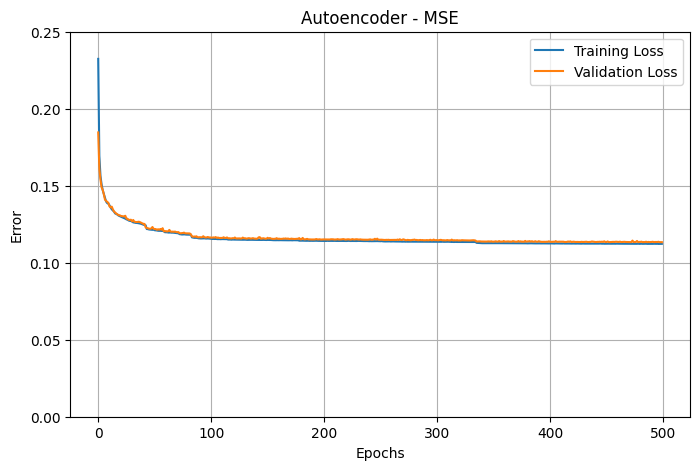

In [ ]:
# Extract loss values for plotting
loss_values = history.history['loss']

# Extract validation loss values for plotting
val_loss_values = history.history['val_loss']
# Create the plot
plt.figure(figsize=(8, 5))

# Plot training loss
plt.plot(loss_values, linestyle='-', label='Training Loss')

plt.plot(val_loss_values, linestyle='-', label='Validation Loss')
plt.ylim(0, 0.25)
# Plot legend
plt.legend(loc='best')
# Add labels and title
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.title('Autoencoder - Mean Squared Error (MSE)')
plt.grid(True)
plt.legend()
# Show the plot
plt.show()

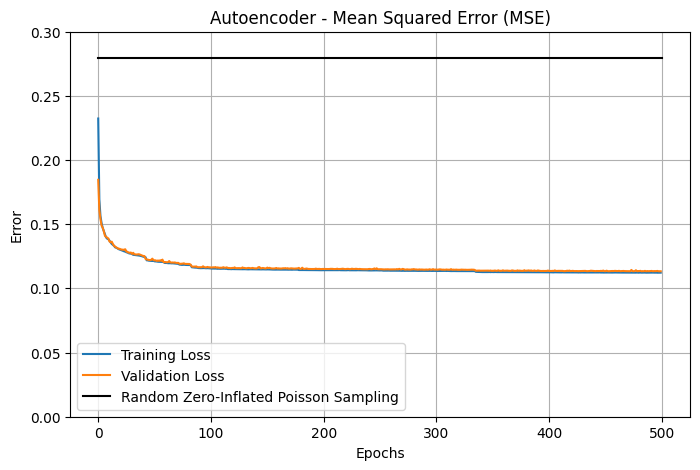

In [ ]:
# Extract loss values for plotting
loss_values = history.history['loss']

# Extract validation loss values for plotting
val_loss_values = history.history['val_loss']
# Create the plot
plt.figure(figsize=(8, 5))
# Plot training loss
plt.plot(loss_values, linestyle='-', label='Training Loss')

plt.plot(val_loss_values, linestyle='-', label='Validation Loss')
plt.plot([0, 500], [0.2799, 0.2799], color='black', linestyle='-', label='Random Zero-Inflated Poisson Sampling')
# Plot legend
plt.legend(loc='best')
plt.ylim(0, 0.3)
# Add labels and title
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.title('Autoencoder - Mean Squared Error (MSE)')
plt.grid(True)
plt.legend()
plt.savefig("autoencoder_training.png", dpi = 600)
# Show the plot
plt.show()

In [ ]:
import numpy as np
import statsmodels.formula.api as smf
import pandas as pd
random_loss = []
# Convert test_features to a pandas DataFrame for model fitting
df = pd.DataFrame(train_features.flatten(), columns=['y'])

# Fit the Zero-Inflated Poisson model
zip_model = smf.poisson('y ~ 1', data=df).fit()
lambda_hat = np.exp(zip_model.params['Intercept'])

# Estimate the zero-inflation probability
zero_count = (df['y'] == 0).sum()
total_count = len(df)
observed_zero_prob = zero_count / total_count
fitted_poisson_zero_prob = np.exp(-lambda_hat)
inflation_prob_hat = (observed_zero_prob - fitted_poisson_zero_prob) / (1 - fitted_poisson_zero_prob)

# Function to sample from the fitted ZIP distribution
def sample_from_fitted_zip(lambda_hat, inflation_prob_hat, shape):
    poisson_samples = np.random.poisson(lambda_hat, size=shape)
    zero_inflation = np.random.binomial(1, inflation_prob_hat, size=shape)
    zero_inflated_samples = np.where(zero_inflation == 1, 0, poisson_samples)
    return zero_inflated_samples

random_loss = []
shape = (14433, 2766)

for i in range(500):
    print(i)
    # Generate the array with values sampled from the fitted ZIP distribution
    random_array = sample_from_fitted_zip(lambda_hat, inflation_prob_hat, shape)
    random_loss.append(zero_inflated_mse(test_features, random_array))

In [ ]:
sampled_values = np.random.choice(random_loss, size=500, replace=True)

# Generate Gaussian distribution based on sampled values
mean = np.mean(sampled_values)
std_dev = np.std(sampled_values)
gaussian_values = np.random.normal(loc=mean, scale=std_dev, size=500)

# Store the Gaussian values in a new list
new_list = list(gaussian_values)

In [ ]:
history = pd.read_csv("autoencoder_training.csv")

In [ ]:
history['val_loss']

0      0.123696
1      0.109067
2      0.105690
3      0.103134
4      0.101675
         ...   
495    0.117258
496    0.117321
497    0.117561
498    0.117321
499    0.117776
Name: val_loss, Length: 500, dtype: float64

In [ ]:
history = pd.DataFrame(history.history)
history.to_csv("autoencoder_training.csv")

In [ ]:
autoencoder.save("autoencoder_v10.keras")

In [ ]:
# Extract the trained encoder
trained_encoder = autoencoder.layers[0]

In [ ]:
latent = trained_encoder.predict(in_data)

2256/2256 [==============================] - 3s 1ms/step


In [ ]:
pd.DataFrame(latent)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.534857,1.261585,2.037741,0.227763,-2.186131,0.291034,0.208045,0.639917,0.673473,0.238666,...,-0.080727,-0.878416,-0.825832,0.920783,-5.025216,-1.395970,-0.136044,0.523884,0.104903,-1.074517
1,-0.566214,0.190840,0.139695,0.580820,-0.315527,0.448870,0.284390,-0.174782,0.012693,0.591491,...,0.171614,-0.482929,-0.902714,0.531158,-1.386434,0.324002,0.120751,-0.055527,-0.245607,0.657546
2,0.160800,-0.068358,1.298587,-0.352607,-5.401760,-0.362190,-1.109678,0.231335,0.748599,-0.404623,...,-1.864939,0.347732,0.556697,-0.091083,-3.867340,1.958574,-0.311745,-0.979371,1.306971,0.087245
3,-0.198635,0.783020,-0.211301,-0.315710,0.744162,0.628873,1.111918,-1.333561,-0.750284,0.523638,...,0.574917,1.441675,1.110091,1.213243,-2.749565,-1.080307,-0.656475,-1.754776,-1.874849,0.046360
4,-0.756760,-0.324429,0.619798,0.404095,-1.009291,0.564649,0.012472,-0.044891,0.340012,-0.529317,...,-0.832746,-0.869706,-0.292874,-0.398040,-0.654988,0.065388,-0.016004,0.201723,-0.175129,0.300454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72160,-0.445976,0.552297,-0.267923,0.043453,-0.240224,-0.416330,-0.471904,-0.108422,-0.250063,0.374220,...,0.364330,-0.327698,-0.551058,0.130074,-0.267225,1.001000,0.029590,-0.130140,-0.700207,-0.346845
72161,-0.337123,0.568957,-3.049730,0.701747,0.380251,0.669445,1.180852,-0.749006,0.556931,-0.671701,...,1.909600,0.794941,0.245526,0.085451,-3.539732,-0.325575,0.491380,-0.279220,1.492202,0.322228
72162,-1.231228,1.916305,-0.922833,-0.363062,-3.038353,0.656963,0.809127,0.057840,-0.529285,0.185413,...,-2.413101,-2.227933,-1.161937,-0.199516,-1.379777,2.515702,-0.400953,-3.119275,-0.401511,-0.917332
72163,-0.242346,-0.318366,-0.696402,-0.383769,-0.644845,-0.178623,-1.225003,-0.025390,0.025423,0.060920,...,0.304944,0.333562,-0.372866,0.095642,-0.373046,0.292441,-0.374490,-0.086206,0.080121,-0.347890


In [ ]:
latent = pd.DataFrame(latent)
latent.to_csv("latent_v10.csv")

In [ ]:
trained_decoder = autoencoder.layers[1]

In [ ]:
out = trained_decoder.predict(latent)

2256/2256 [==============================] - 3s 1ms/step


In [ ]:
out = pd.DataFrame(out)

In [ ]:
in_data

,A2M,AAGAB,AAK1,ABCA2,ABCA7,ABCC9,ABHD17A,ABHD17B,ABHD17C,ABHD6,...,ZFP36,ZFP536,ZFP60,ZFP605,ZFP750,ZHX1,ZIC1,ZIM1,ZMYM1,ZMYM2
17463,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,1.365241,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17464,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17465,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17466,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17467,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55773,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55774,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55775,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55776,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.799207,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
out.columns = in_data.columns

In [ ]:
out

,A2M,AAGAB,AAK1,ABCA2,ABCA7,ABCC9,ABHD17A,ABHD17B,ABHD17C,ABHD6,...,ZFP36,ZFP536,ZFP60,ZFP605,ZFP750,ZHX1,ZIC1,ZIM1,ZMYM1,ZMYM2
0,0.000000,0.108706,0.000000,0.0,0.000000,0.500643,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.828719,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.072622,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.544792
2,0.000000,0.000000,0.242638,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.281185,0.0,0.000000,0.000000,0.422679
3,0.073666,0.000000,0.000000,0.0,0.007726,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,1.155751,0.0,0.000000,0.000000,1.116523
4,0.000000,0.031708,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.102403,0.0,1.052262,0.0,0.474214,0.000000,0.587308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72160,0.188537,0.057095,0.000000,0.0,0.034193,0.000000,0.0,0.0,0.301080,0.178291,...,0.0,0.000000,0.000000,0.379635,0.0,0.180721,0.0,0.000000,0.000000,0.753134
72161,0.000000,0.000000,0.914681,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.268764
72162,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.696516,0.0,0.000000,0.000000,0.000000
72163,0.363738,0.000000,0.000000,0.0,0.299285,0.089802,0.0,0.0,0.237002,0.000000,...,0.0,0.000000,0.037587,0.184596,0.0,0.505783,0.0,0.000000,0.346643,0.376479


In [ ]:
gene_labels = ['GRN', 'CTSL', 'CTSS', 'CCL6', 'FAM20C', 'H2-AA', 'CST7', 'ITGB5', 'CLEC7A', 'GPNMB', 'LYZ2', 'HEXB']

In [ ]:
y_true = in_data[gene_labels]

In [ ]:
y_pred = out[gene_labels]

In [ ]:
in_data.index = range(0,72165)

In [ ]:
from sklearn.metrics import mean_squared_error

# Calculate the mean squared error (MSE) for two subsets of data and then average them.


def zero_inflated_mse(y_true, y_pred):

    y_true = y_true.to_numpy()
    y_pred = y_pred.to_numpy()
    # Ensure no NaN values are present
    if np.isnan(y_true).any() or np.isnan(y_pred).any():
        raise ValueError("Input arrays must not contain NaN values.")

    # Separate data into zeros and non-zeros
    zeros_mask = (y_true == 0)
    non_zeros_mask = ~zeros_mask

    # Calculate mean squared error for non-zeros
    mse_non_zeros = mean_squared_error(y_true[non_zeros_mask], y_pred[non_zeros_mask])
    print(mse_non_zeros)
    mse_zeros = mean_squared_error(y_true[zeros_mask], y_pred[zeros_mask])
    print(mse_zeros)

    zero_inflated_mse = (mse_zeros+mse_non_zeros)/2

    return zero_inflated_mse

In [ ]:
zero_inflated_mse(y_true, y_pred)

0.15013496621876685
0.047569060873602166


0.0988520135461845